<a href="https://colab.research.google.com/github/juliacporto-creator/Estatistica-/blob/main/Tarefa06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

- Julia Porto 17901372
- Larissa Mei
- Marianne Adorno 17995367


# Regressão linear simples e correlação linear de Pearson
 Para tal atividade, foi utilizado um conjunto de dados a fim de avaliar a relação linear inversa entre a Atividade de Água ($a_w$) e a Durabilidade/Vida de Prateleira (em dias) de diferentes amostras de frutas (in natura, desidratadas e liofilizadas), sob armazenamento controlado a 20 °C.

 Fonte dos Dados: Dados adaptados e compilados a partir da literatura de microbiologia de alimentos e isotermas de sorção para matrizes de frutas estocadas a 20 °C.

Responsável: Compilação por inteligência artificial para fins de modelagem estatística em Ciência de Alimentos.

Data de Criação/Acesso: 17 de agosto de 2026.

In [ ]:
import pandas as pd

In [ ]:
import pandas as pd

# Replace 'your_file.xlsx' with the actual path to your Excel file
# Note: There isn't a sample Excel file by default, so you would need to upload one or provide a valid path.
excel_file_path = '/content/Atividade de Água X Duração.xlsx'
df_excel = pd.read_excel(excel_file_path)

print("First 5 rows of the Excel data:")
display(df_excel)

First 5 rows of the Excel data:


,Amostra de Fruta,Estado / Processamento,Atividade de Água (aw​),Durabilidade (dias)
0,Banana,Liofilizada,0.18,360
1,Morango,Liofilizado,0.25,330
2,Maçã,Liofilizada,0.32,300
3,Manga,Liofilizada,0.40,265
4,Abacaxi,Liofilizado,0.48,230
5,Uva,Desidratada,0.62,160
6,Ameixa,Passa / Semi-úmida,0.75,110
7,Mamão,In Natura,0.88,50
8,Morango,In Natura,0.95,18
9,Melancia,In Natura,0.98,7


#Descrição das Variáveis
- Atividade de Água ($X$): Variável independente adimensional ($a_w$) correspondente à água livre disponível para reações químicas e desenvolvimento microbiológico no alimento (escala de 0 a 1).
- Durabilidade ($Y$): Variável dependente contínua expressa em dias, representando o tempo limite de estocagem antes de deterioração sensorial ou microbiológica.






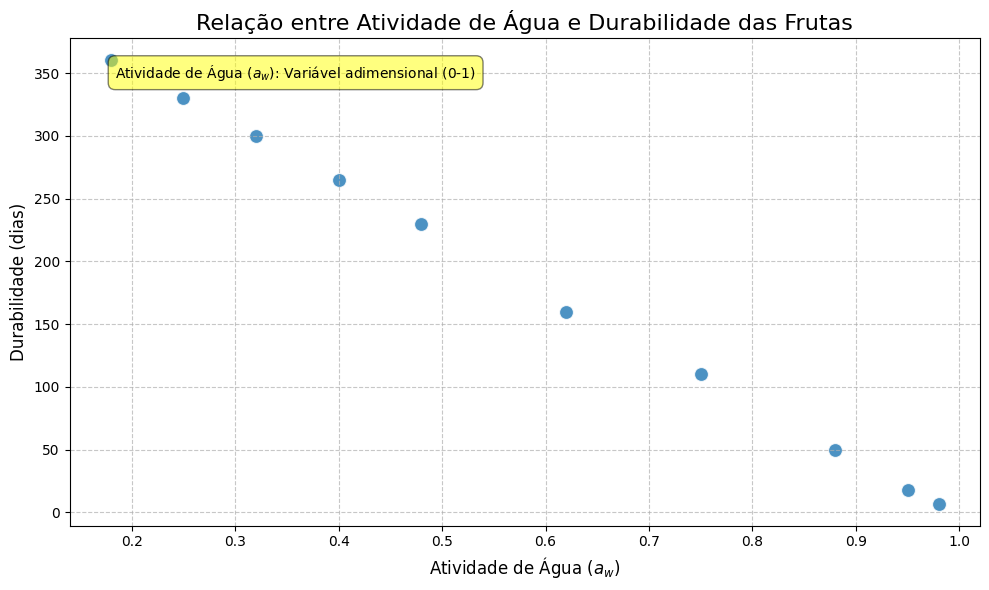

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_excel, x='Atividade de Água (aw​)', y='Durabilidade (dias)', s=100, alpha=0.8)

# Add title and labels with units
plt.title('Relação entre Atividade de Água e Durabilidade das Frutas', fontsize=16)
plt.xlabel('Atividade de Água ($a_w$)', fontsize=12)
plt.ylabel('Durabilidade (dias)', fontsize=12)

# Add an annotation for 'Atividade de Água (aw)'
plt.text(0.05, 0.95, 'Atividade de Água ($a_w$): Variável adimensional (0-1)', transform=plt.gca().transAxes, fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.5))

# Add grid for better readability
plt.grid(True, linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()

# O que é regressão linear simples?
É um método da estatística usado para relacionar duas variáveis numéricas contínuas  , sendo que, uma variável é independente (a causa, sempre presente no eixo X) e uma variável é dependente  (o efeito, sempre presente no eixo Y).
Dessa maneira, a regressão linear busca a maneira mais adequada de associar os dados, além de permitir a previsão de Y com base nos valores de X.



In [ ]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Define the independent (X) and dependent (y) variables
# Ensure X is a 2D array for sklearn
X = df_excel[['Atividade de Água (aw​)']].values
y = df_excel['Durabilidade (dias)'].values

# Create a linear regression model
model = LinearRegression()

# Fit the model to the data
model.fit(X, y)

# Get the coefficients
# The slope (coefficient for X)
slope = model.coef_[0]
# The intercept (constant term)
intercept = model.intercept_

print(f"Coeficiente (inclinação): {slope:.2f}")
print(f"Intercepto: {intercept:.2f}")

Coeficiente (inclinação): -444.40
Intercepto: 441.20


### Interpretação dos Coeficientes:

*   **Intercepto:** É o ponto onde a reta cruza o eixo Y, representando o valor esperado de Y quando X for igual a zero. Dessa forma, o valor do intercepto representa a durabilidade esperada (em dias) quando a Atividade de Água ($a_w$) é zero. No contexto dos alimentos, $a_w = 0$ significa que não há água disponível, o que implica em uma durabilidade muito alta ou indefinida. Este valor deve ser interpretado com cuidado pois, embora a escala varie de 0 à 1, nenhum alimento possui absolutamente zero moléculas de água livres, podendo assim estar fora do intervalo de dados observados.

*   **Coeficiente (Inclinação):** O coeficiente (inclinação da reta) indica a mudança na durabilidade (em dias) para cada aumento de uma unidade na Atividade de Água ($a_w$). Como a Atividade de Água e a Durabilidade são inversamentes proporcionais, o coeficiente é negativo, significando que, à medida que a Atividade de Água aumenta, a Durabilidade do produto diminui.

### Fórmula da Regressão Linear Simples

A equação de uma regressão linear simples é expressa como:

$$ \hat{Y} = \beta_0 + \beta_1 X + \epsilon $$

Onde:

*   $ \hat{Y} $ é o valor predito da variável dependente.
*   $ \beta_0 $ (beta zero) é o **intercepto** (o valor de $ \hat{Y} $ quando $ X = 0 $).
*   $ \beta_1 $ (beta um) é o **coeficiente angular** ou **inclinação** (a mudança média em $ \hat{Y} $ para cada aumento de uma unidade em $ X $).
*   $ X $ é a variável independente.
*   $ \epsilon $ (epsilon) é o termo de erro, representando a variabilidade não explicada pelo modelo.

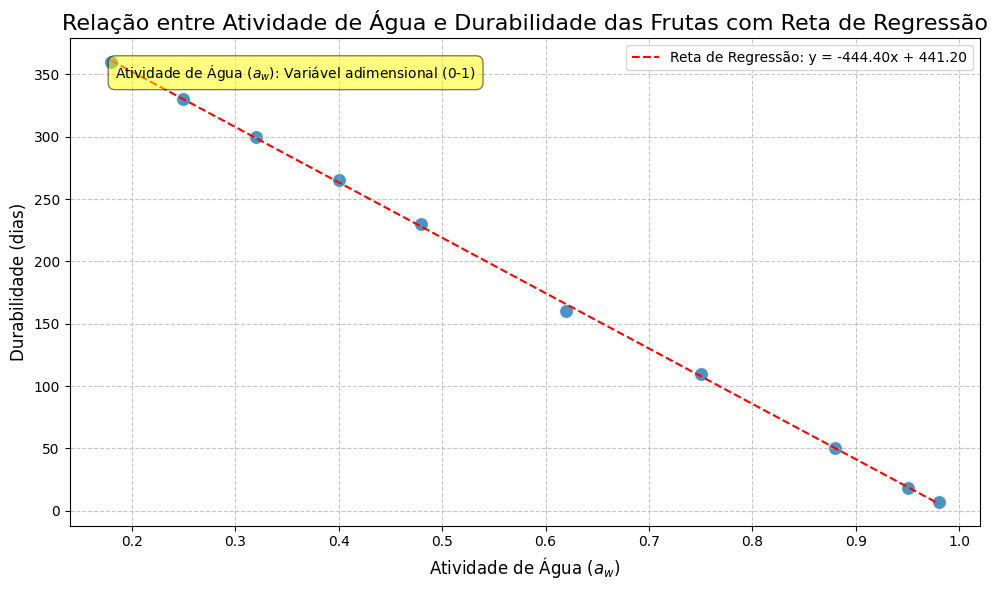

In [ ]:
# Generate predictions for the regression line
y_pred = model.predict(X)

# Add the regression line to the existing scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_excel, x='Atividade de Água (aw​)', y='Durabilidade (dias)', s=100, alpha=0.8)
plt.plot(X, y_pred, color='red', linestyle='--', label=f'Reta de Regressão: y = {slope:.2f}x + {intercept:.2f}')

# Add title and labels with units
plt.title('Relação entre Atividade de Água e Durabilidade das Frutas com Reta de Regressão', fontsize=16)
plt.xlabel('Atividade de Água ($a_w$)', fontsize=12)
plt.ylabel('Durabilidade (dias)', fontsize=12)

# Add an annotation for 'Atividade de Água (aw)'
plt.text(0.05, 0.95, 'Atividade de Água ($a_w$): Variável adimensional (0-1)', transform=plt.gca().transAxes, fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.5))

# Add grid for better readability
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()

### O que é a Correlação Linear de Pearson?

A Correlação Linear de Pearson, frequentemente denotada por $r$, é uma medida estatística que quantifica a **força** e a **direção** de uma associação linear entre duas variáveis numéricas contínuas. O coeficiente de correlação de Pearson varia de -1 a +1:

*   **+1:** Indica uma relação linear positiva perfeita. À medida que uma variável aumenta, a outra também aumenta de forma consistente.
*   **-1:** Indica uma relação linear negativa perfeita. À medida que uma variável aumenta, a outra diminui de forma consistente.
*   **0:** Indica que não há relação linear entre as duas variáveis. É importante notar que isso não significa que não há nenhuma relação, apenas que não há uma relação linear, não é possível traçar uma linha reta que consiga prever Y com base em X.

Quanto mais próximo de +1 ou -1 o valor de $r$ estiver, mais forte é a relação linear, o sinal indicando a direção (positiva ou negativa).

In [ ]:
import pandas as pd

# Define the path to the Excel file (assuming it's already uploaded to /content/)
excel_file_path = '/content/Atividade de Água X Duração.xlsx'

# Load the Excel data into a DataFrame
df_excel = pd.read_excel(excel_file_path)

# Calculate Pearson's correlation coefficient
correlation = df_excel['Atividade de Água (aw​)'].corr(df_excel['Durabilidade (dias)'])

print(f"Coeficiente de Correlação de Pearson: {correlation:.2f}")

Coeficiente de Correlação de Pearson: -1.00


# Qual a correlação?

    O Coeficiente de Correlação de Pearson é -1.00.

A correlação encontrada é negativa e por ter o valor de -1.00 indica uma relação linear negativa perfeita. Ou seja, à medida que a Atividade de Água ($a_w$$a_w$) aumenta, a Durabilidade (dias) diminui de forma consistente e proporcional.

### Interpretação do Coeficiente de Correlação de Pearson:

O valor do coeficiente de correlação de Pearson indica:

*   **Força:** Quão forte é a relação linear entre a Atividade de Água e a Durabilidade.
*   **Direção:** Se a relação é positiva (ambas as variáveis aumentam juntas) ou negativa (uma variável aumenta enquanto a outra diminui).

Um valor próximo de -1 sugere uma forte relação linear inversa,alinhado com a ideia de que a durabilidade diminua à medida que a atividade de água aumenta.

### Fórmula do Coeficiente de Correlação de Pearson

O coeficiente de correlação de Pearson ($r$) é calculado pela seguinte fórmula:

$$ r = \frac{n\sum XY - (\sum X)(\sum Y)}{\sqrt{[n\sum X^2 - (\sum X)^2][n\sum Y^2 - (\sum Y)^2]}} $$

Onde:

*   $ n $ é o número de pares de dados.
*   $ \sum XY $ é a soma dos produtos de $ X $ e $ Y $.
*   $ \sum X $ e $ \sum Y $ são as somas de $ X $ e $ Y $, respectivamente.
*   $ \sum X^2 $ e $ \sum Y^2 $ são as somas dos quadrados de $ X $ e $ Y $, respectivamente.

### Correlação Próxima de Zero

Quando o coeficiente de correlação de Pearson é igual ou próximo de zero, isso indica ausência de uma relação linear entre as duas variáveis. Ou seja, não há uma tendência clara de que uma variável aumente ou diminua de forma consistente com a outra em um padrão reto.

No entanto, uma correlação próxima de zero não significa necessariamente ausência de qualquer tipo de relação entre as variáveis. Elas podem ter uma relação não linear (curvilínea), como uma curva em forma de U, que a correlação de Pearson, por ser uma medida de linearidade, não conseguiria capturar. Em tais casos, outras ferramentas de análise e visualização (como gráficos de dispersão) seriam necessárias para identificar a verdadeira natureza da relação.

### Conclusão: Relação entre Atividade de Água e Durabilidade, e a utilidade da regressão e da correlação em Alimentos

A análise de regressão linear simples e o coeficiente de correlação de Pearson revelam uma relação linear negativa perfeita entre a Atividade de Água ($a_w$) e a Durabilidade (vida de prateleira) das frutas. O coeficiente de Pearson de -1.00, junto com o coeficiente de inclinação negativo da regressão linear, indica que à medida que a Atividade de Água aumenta, a Durabilidade do produto diminui, de forma diretamente proporcional e consistente.

#### Utilidade para a Ciência de Alimentos:

**Compreensão:** Esta relação é um pilar da ciência da conservação de alimentos. A água livre ($a_w$) influencia o crescimento microbiano e a ocorrência de reações enzimáticas e químicas indesejadas que levam à deterioração.

**Previsão de Vida de Prateleira:** A regressão linear simples, neste caso, oferece uma ferramenta para prever a durabilidade de produtos alimentícios com base em sua Atividade de Água. Sendo assim fundamental para o desenvolvimento de novos produtos, melhoria de formulações e definição de condições de armazenamento.

**Controle de Qualidade e Processamento:** Ao estudar essa relação, a indústria de alimentos pode estabelecer limites de $a_w$ para garantir a estabilidade e segurança dos produtos, otimizando processos como secagem, desidratação e embalagem.

**Validação:** A alta correlação permite validar a eficácia de intervenções que visam reduzir a Atividade de Água para prolongar a vida útil do produto.

Sendo assim, a regressão linear e a correlação de Pearson são ferramentas estatísticas indispensáveis na ciência de alimentos. Elas permitem não apenas identificar e quantificar as relações entre variáveis críticas (como $a_w$ e durabilidade), mas também encontrar padrões e prever comportamentos ou valores futuros, o que é essencial para a inovação, segurança e qualidade alimentar.